# pycelladmix quickstart

Identify and correct cell admixtures in imaging-based spatial transcriptomics — Python port of [`cellAdmix`](https://github.com/kharchenkolab/cellAdmix) (Mitchel et al. 2025).

This tutorial demonstrates the full pipeline on a synthetic dataset where some molecules are deliberately mis-assigned to neighbouring cells (simulating a segmentation error). The pipeline should:

1. Factorise spatial neighbourhoods of molecules with NMF.
2. Smooth per-molecule factor assignments with a CRF.
3. Compute a per-cell Bayesian admixture score against an scRNA-seq reference.

Cells with admixture should score higher than clean cells.

All numerically heavy steps run on JAX, GPU-accelerated where available.

In [1]:
from __future__ import annotations

import jax
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import sparse

import pycelladmix

print(f"pycelladmix {pycelladmix.__version__}")
print(f"JAX backend: {jax.default_backend()}")

pycelladmix 0.0.1


JAX backend: gpu


## 1. Synthetic data with admixture

We simulate **3 cell types** (A, B, C) arranged on a 6×6 grid in 2D + small z. Each cell has 80 molecules. Each cell type expresses 10 type-specific marker genes plus a small fraction of background genes.

Then we **inject admixture** into half the cells of type A: ~25% of their molecules are stolen from a neighbouring cell of type B (simulating a segmentation error where a B-cell molecule got assigned to its A-cell neighbour). These cells should be flagged as high-admixture by the pipeline.

In [2]:
rng = np.random.default_rng(0)

cell_types = ["A", "B", "C"]
n_grid = 6
n_mols_per_cell = 80
n_markers_per_type = 10

gene_names = []
type_to_genes = {}
for ct in cell_types:
    genes = [f"{ct}_g{i}" for i in range(n_markers_per_type)]
    type_to_genes[ct] = genes
    gene_names.extend(genes)

cells_meta: list[dict] = []
cell_id = 0
for i in range(n_grid):
    for j in range(n_grid):
        ct = cell_types[(i + j) % 3]
        cells_meta.append(
            {"cell": f"cell_{cell_id}", "celltype": ct, "cx": i * 10.0, "cy": j * 10.0}
        )
        cell_id += 1
cells_df = pd.DataFrame(cells_meta)

# Build per-molecule rows (clean version)
rows: list[dict] = []
for _, c in cells_df.iterrows():
    for m in range(n_mols_per_cell):
        # 85% type-marker, 15% background
        if rng.random() < 0.85:
            g = rng.choice(type_to_genes[c["celltype"]])
        else:
            g = rng.choice(gene_names)
        rows.append({
            "x": c["cx"] + rng.normal(0, 2.0),
            "y": c["cy"] + rng.normal(0, 2.0),
            "z": rng.normal(0, 0.5),
            "gene": g,
            "cell": c["cell"],
            "celltype": c["celltype"],
        })

df_clean = pd.DataFrame(rows)
df_clean["mol_id"] = [f"m{i:06d}" for i in range(len(df_clean))]
print(f"{len(df_clean)} molecules, {df_clean['cell'].nunique()} cells, {df_clean['gene'].nunique()} genes")

2880 molecules, 36 cells, 30 genes


In [3]:
# Inject admixture: pick a fraction of A-cells, replace 25% of their molecules with
# B-marker counts (as if a neighbouring B cell's molecules had been mis-assigned).
df = df_clean.copy()
admixed_cells = (
    df[df["celltype"] == "A"]["cell"].drop_duplicates()
    .sample(frac=0.5, random_state=1).tolist()
)
admix_mask = (df["cell"].isin(admixed_cells)) & (rng.random(len(df)) < 0.25)
new_genes = rng.choice(type_to_genes["B"], size=int(admix_mask.sum()))
df.loc[admix_mask, "gene"] = new_genes
print(f"{len(admixed_cells)} A-cells received admixture")
print(f"{int(admix_mask.sum())} molecules ({admix_mask.mean() * 100:.1f}%) flipped to B markers")

6 A-cells received admixture
101 molecules (3.5%) flipped to B markers


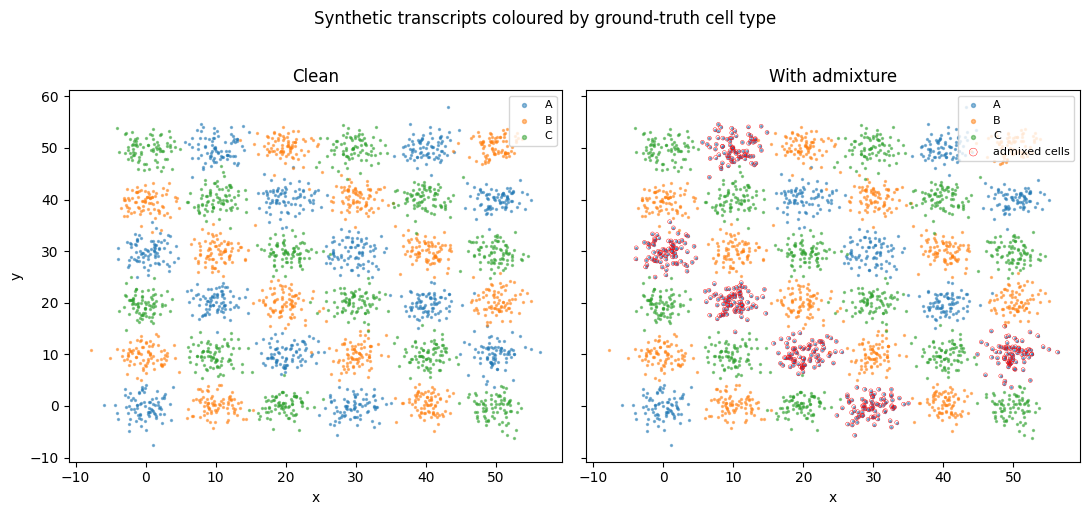

In [4]:
# Visualise: x-y layout coloured by ground-truth cell type, before vs after admixture.
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
palette = {"A": "#1f77b4", "B": "#ff7f0e", "C": "#2ca02c"}

for ax, frame, title in [(axes[0], df_clean, "Clean"), (axes[1], df, "With admixture")]:
    for ct, color in palette.items():
        sub = frame[frame["celltype"] == ct]
        ax.scatter(sub["x"], sub["y"], c=color, s=2, alpha=0.5, label=ct)
    # highlight admixed cells in panel 2
    if frame is df:
        admix_sub = frame[frame["cell"].isin(admixed_cells)]
        ax.scatter(admix_sub["x"], admix_sub["y"], facecolors="none", edgecolors="red",
                   s=8, linewidths=0.3, label="admixed cells")
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.legend(markerscale=2, loc="upper right", fontsize=8)
axes[0].set_ylabel("y")
fig.suptitle("Synthetic transcripts coloured by ground-truth cell type", y=1.02)
plt.tight_layout()
plt.show()

## 2. Build a synthetic scRNA-seq reference

For Bayesian admixture scoring we need a per-cell-type gene-probability table — typically derived from an external scRNA-seq dataset on the same tissue. Here we synthesise one with strong type specificity.

In [5]:
n_rna_per_type = 50
rna_cells: list[str] = []
rna_types: list[str] = []
n_genes_total = len(gene_names)
rna_counts = np.zeros((n_genes_total, len(cell_types) * n_rna_per_type), dtype=np.float32)
for ti, ct in enumerate(cell_types):
    marker_idx = [gene_names.index(g) for g in type_to_genes[ct]]
    for j in range(n_rna_per_type):
        idx = ti * n_rna_per_type + j
        rna_cells.append(f"rna_{ct}_{j}")
        rna_types.append(ct)
        # Strong markers + low-level background of all genes
        rna_counts[marker_idx, idx] = rng.poisson(8, size=len(marker_idx))
        rna_counts[:, idx] += rng.poisson(0.2, size=n_genes_total)
annot_rna = pd.Series(rna_types, index=rna_cells)
print(f"RNA reference: {rna_counts.shape} (genes x cells)")

RNA reference: (30, 150) (genes x cells)


## 3. Run the pipeline

A single call runs KNN-NMF → CRF → Bayesian admixture scoring. Default parameters mirror the R defaults (k=5, h_nmf=20, h_crf=10, 30 NMF restarts, 200 BP iterations); we use smaller values here for tutorial speed.

In [6]:
%%time
res = pycelladmix.run_celladmix(
    df,
    k=3,
    h_nmf=15,
    h_crf=10,
    nmf_runs=5,
    nmf_iter=200,
    crf_iter=100,
    seed=0,
    weighted_nmf=True,
    cm_rna=sparse.csr_matrix(rna_counts),
    annot_rna=annot_rna,
    rna_gene_names=gene_names,
    p_c=0.25,
    signal_thres=0.1,
    min_expr_frac=0.05,
    adjust_scores=True,
)
print(f"NMF reconstruction error: {res.nmf.reconstruction_error:.2f}  (best seed={res.nmf.seed})")
print(f"CRF returned {len(res.crf)} factor labels")
print(f"Admixture scores computed for {len(res.contamination.cell_admixture_fractions)} cells")

NMF reconstruction error: 25.31  (best seed=0)
CRF returned 2880 factor labels
Admixture scores computed for 36 cells
CPU times: user 12.3 s, sys: 2.13 s, total: 14.5 s
Wall time: 16.6 s


## 4. Inspect NMF gene loadings

Each NMF factor should have high loading on the marker genes of one cell type — i.e. the rank-3 NMF should have learned the three cell-type signatures from spatial neighbourhoods alone.

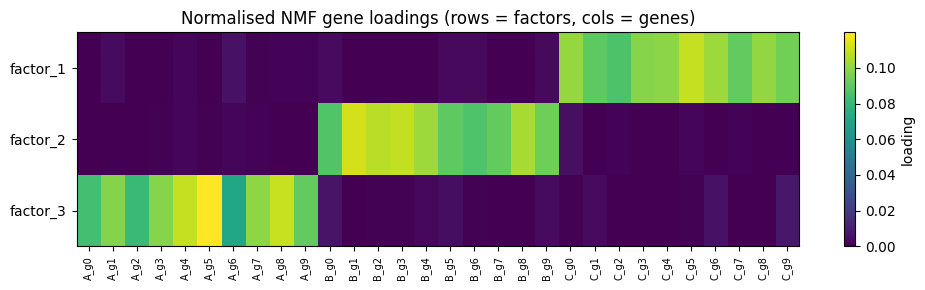

In [7]:
H = np.asarray(res.nmf.H)  # (k, n_genes)
H_norm = H / (H.sum(axis=1, keepdims=True) + 1e-12)
df_h = pd.DataFrame(H_norm, columns=res.nmf.gene_names, index=[f"factor_{i + 1}" for i in range(H.shape[0])])
df_h = df_h[gene_names]  # canonical gene order

fig, ax = plt.subplots(figsize=(10, 3.0))
im = ax.imshow(df_h.values, aspect="auto", cmap="viridis")
ax.set_xticks(np.arange(len(gene_names)))
ax.set_xticklabels(gene_names, rotation=90, fontsize=7)
ax.set_yticks(np.arange(len(df_h.index)))
ax.set_yticklabels(df_h.index)
ax.set_title("Normalised NMF gene loadings (rows = factors, cols = genes)")
plt.colorbar(im, ax=ax, label="loading")
plt.tight_layout()
plt.show()

## 5. CRF factor assignments per cell type

The CRF stage assigns each molecule to one of the k factors using max-product loopy belief propagation over the molecule-KNN graph. Spatial coherence makes molecules of the same cell tend to share a factor.

In [8]:
crf = res.crf.merge(df[["mol_id", "celltype"]], on="mol_id")
contingency = pd.crosstab(crf["celltype"], crf["factor"], normalize="index")
print("CRF factor distribution per ground-truth cell type:")
print(contingency.round(2))

CRF factor distribution per ground-truth cell type:
factor       1     2     3
celltype                  
A         0.02  0.01  0.98
B         0.01  0.98  0.01
C         0.98  0.01  0.01


## 6. Per-cell admixture scores

Cells that received simulated admixture should have **higher** admixture scores than clean cells. We compare the score distributions between the two groups.

         count   mean    std  min  25%  50%   75%    max
group                                                   
admixed    6.0  0.015  0.031  0.0  0.0  0.0  0.01  0.077
clean     30.0  0.000  0.000  0.0  0.0  0.0  0.00  0.000


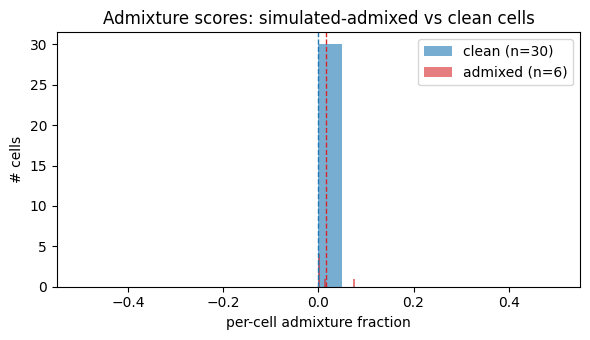

In [9]:
fracs = res.contamination.cell_admixture_fractions
group = pd.Series(
    np.where(fracs.index.isin(admixed_cells), "admixed", "clean"),
    index=fracs.index,
)
df_score = pd.DataFrame({"admixture_score": fracs, "group": group})

print(df_score.groupby("group")["admixture_score"].describe().round(3))

fig, ax = plt.subplots(figsize=(6, 3.5))
for g, color in [("clean", "#1f77b4"), ("admixed", "#d62728")]:
    sub = df_score[df_score["group"] == g]["admixture_score"]
    ax.hist(sub, bins=20, alpha=0.6, label=f"{g} (n={len(sub)})", color=color)
ax.axvline(df_score[df_score["group"] == "clean"]["admixture_score"].mean(),
           color="#1f77b4", linestyle="--", linewidth=1)
ax.axvline(df_score[df_score["group"] == "admixed"]["admixture_score"].mean(),
           color="#d62728", linestyle="--", linewidth=1)
ax.set_xlabel("per-cell admixture fraction")
ax.set_ylabel("# cells")
ax.set_title("Admixture scores: simulated-admixed vs clean cells")
ax.legend()
plt.tight_layout()
plt.show()

## Summary

The pipeline ran end-to-end on synthetic data and the per-cell admixture score successfully discriminated between cells that received simulated contamination and clean cells.

### Next steps

- **Real data**: replace the synthetic transcript dataframe with a Xenium / MERSCOPE / CosMx output (one row per detected molecule with x/y/z/gene/cell columns). The interface is identical.
- **Annotation tests**: `pycelladmix.annotation` exposes the bridge / membrane / enrichment tests for explicit factor-vs-cell-type hypothesis testing — useful when you want to *correct* (not just score) admixture by removing molecules of selected (factor, cell-type) pairs.
- **Larger panels and more cells**: NMF and CRF stages run in JAX, so scaling to tissue-wide datasets primarily benefits from a GPU. The R reference handles ≲100k molecules well; this port targets ≳1M.

### Citation

Mitchel J., Petukhov V., Gao T., Kharchenko P. *cellAdmix: identifying and correcting cell admixtures in spatial transcriptomics.* bioRxiv 2025.
